In [10]:
import os
os.getcwd()

'/Users/sophiepalmer/Documents/Projects/hawaii-wildfire'

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import rasterio
import rioxarray
import pystac
import geopandas as gpd

In [14]:
tif_path = "data/elevation/LF2020_Elev_220_HI/Tif/LH20_Elev_220.tif"

raster_elev = rioxarray.open_rasterio(tif_path) # xarray.DataArray object
# take a look at shape and attributes
raster_elev 

<xarray.DataArray (band: 1, y: 12602, x: 20385)> Size: 514MB
[256891770 values with dtype=int16]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 163kB -3.751e+05 -3.751e+05 ... 2.364e+05 2.364e+05
  * y            (y) float64 101kB 1.028e+06 1.028e+06 ... 6.502e+05 6.502e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:           Area
    RepresentationType:      ATHEMATIC
    STATISTICS_COVARIANCES:  11081281.25824987
    STATISTICS_MAXIMUM:      4199
    STATISTICS_MEAN:         -8829.9575847494
    STATISTICS_MINIMUM:      -9999
    STATISTICS_SKIPFACTORX:  1
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       3328.8558482232
    _FillValue:              32767
    scale_factor:            1.0
    add_offset:              0.0

In [17]:
raster_elev.rio.width * raster_elev.rio.height

256891770

We have an xarray.DataArray with:
- 1 band
- 12,602 rows (y)
- 20,385 columns (x)
- 256,891,770 pixels of signed integer type

In [30]:
# CRS
print(raster_elev.rio.crs)
# Nodata value encoding
print(raster_elev.rio.nodata)
# Bbox corners
print(raster_elev.rio.bounds())
# width
print(raster_elev.rio.width)
# height
print(raster_elev.rio.height)

ESRI:102007
32767
(-375135.00000000064, 650192.986736916, 236414.99999999936, 1028252.986736916)
20385
12602


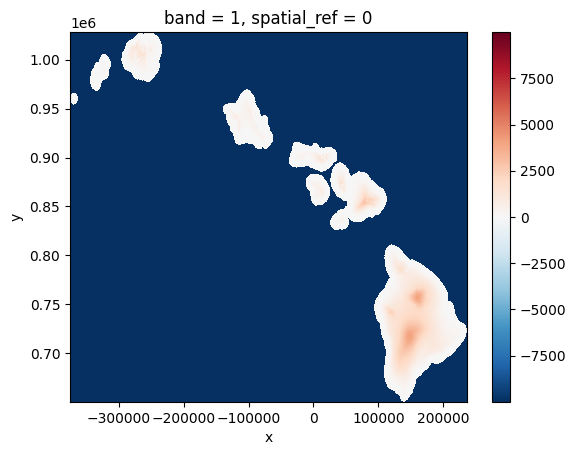

In [32]:
# visualise raster
raster_elev.plot()

In [35]:
print(raster_elev.min())
print(raster_elev.max())
print(raster_elev.mean())
print(raster_elev.std())
print(raster_elev.quantile([0.25, 0.75]))

<xarray.DataArray ()> Size: 2B
array(-9999, dtype=int16)
Coordinates:
    spatial_ref  int64 8B 0
<xarray.DataArray ()> Size: 2B
array(4199, dtype=int16)
Coordinates:
    spatial_ref  int64 8B 0
<xarray.DataArray ()> Size: 8B
array(-8829.95758475)
Coordinates:
    spatial_ref  int64 8B 0
<xarray.DataArray ()> Size: 8B
array(3328.85584174)
Coordinates:
    spatial_ref  int64 8B 0
<xarray.DataArray (quantile: 2)> Size: 16B
array([-9999., -9999.])
Coordinates:
  * quantile  (quantile) float64 16B 0.25 0.75


The most common value is -9999, which (by looking at the image above) I think corresponds to all of the non-land area. So, we're only really interested in the values of 0 and above, as they correspond to the land areas. Note this is different to the nodata value, which is 32767 (though given the max value in the raster is 4199, it looks as though there are no "misisng" data values).

I still want to calculate the summary statistics after removing the sea areas, so removing the -9999 values. Let's change them to NaN for now.

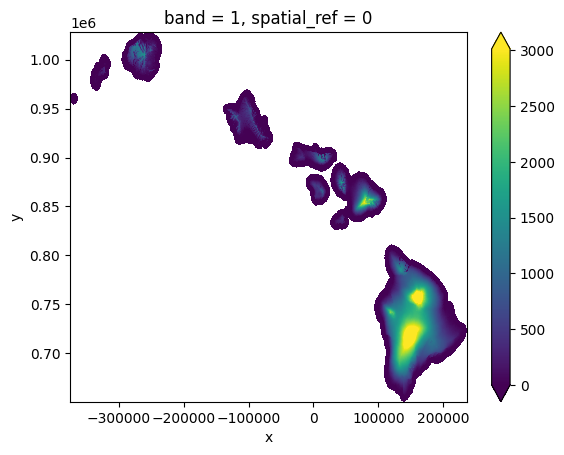

In [ ]:
raster_elev = raster_elev.where(raster_elev != -9999) # this converts -9999 -> NaN
raster_elev.plot(robust=True)

In [39]:
print(raster_elev.min())
print(raster_elev.max())
print(raster_elev.mean())
print(raster_elev.std())
print(raster_elev.quantile([0.25, 0.75]))

<xarray.DataArray ()> Size: 4B
array(-3., dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
<xarray.DataArray ()> Size: 4B
array(4199., dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
<xarray.DataArray ()> Size: 4B
array(585.24866, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
<xarray.DataArray ()> Size: 4B
array(821.3153, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
<xarray.DataArray (quantile: 2)> Size: 16B
array([  0., 911.])
Coordinates:
  * quantile  (quantile) float64 16B 0.25 0.75


In [9]:
# since our raster is just one band, we can remove the band dimension
# to make it easier to work with
elevation = raster_elev.squeeze()
# now it's just a 2D array with .values gives you a NumPy array of 
# elevation values

In [14]:
elevation.where(~elevation.isnull())

<xarray.DataArray (y: 12602, x: 20385)> Size: 1GB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(12602, 20385), dtype=float32)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 163kB -3.751e+05 -3.751e+05 ... 2.364e+05 2.364e+05
  * y            (y) float64 101kB 1.028e+06 1.028e+06 ... 6.502e+05 6.502e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:           Area
    RepresentationType:      ATHEMATIC
    STATISTICS_COVARIANCES:  11081281.25824987
    STATISTICS_MAXIMUM:      4199
    STATISTICS_MEAN:         -8829.9575847494
    STATISTICS_MINIMUM:      -9999
    STATISTICS_SKIPFACTORX:  1
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       3328.8558482232
    _FillValue:              32767
    scale_factor:            1.0
    add_offset:              0.0

In [5]:
raster_elev2 = rioxarray.open_rasterio("data/elevation/LF2020_Elev_220_HI/Tif/LH20_Elev_220.tif")
# remove band dimension (1-band raster)
raster_elev2 = raster_elev2.squeeze()

In [8]:
raster_elev2

<xarray.DataArray (y: 12602, x: 20385)> Size: 514MB
array([[-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       ...,
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999]],
      shape=(12602, 20385), dtype=int16)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 163kB -3.751e+05 -3.751e+05 ... 2.364e+05 2.364e+05
  * y            (y) float64 101kB 1.028e+06 1.028e+06 ... 6.502e+05 6.502e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:           Area
    RepresentationType:      ATHEMATIC
    STATISTICS_COVARIANCES:  11081281.25824987
    STATISTICS_MAXIMUM:      4199
    STATISTICS_MEAN:         -8829.9575847494
    STATISTICS_MINIMUM:      -9999
    STATISTICS_SKIPFACTORX:  1
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       3328.8558482232
    _FillValue:              32767
    scale_factor:            1.0
    add_offset:              0.0

In [14]:
df = raster_elev2.to_dataframe(name='elevation').reset_index()

In [15]:
df

,y,x,band,spatial_ref,elevation
0,1.028238e+06,-375120.0,1,0,-9999
1,1.028238e+06,-375090.0,1,0,-9999
2,1.028238e+06,-375060.0,1,0,-9999
3,1.028238e+06,-375030.0,1,0,-9999
4,1.028238e+06,-375000.0,1,0,-9999
...,...,...,...,...,...
256891765,6.502080e+05,236280.0,1,0,-9999
256891766,6.502080e+05,236310.0,1,0,-9999
256891767,6.502080e+05,236340.0,1,0,-9999
256891768,6.502080e+05,236370.0,1,0,-9999


In [4]:
raster_elev = rioxarray.open_rasterio("data/elevation/LF2020_Elev_220_HI/Tif/LH20_Elev_220.tif")
df = raster_elev.to_dataframe(name='elevation').reset_index()

In [5]:
df

,band,y,x,spatial_ref,elevation
0,1,1.028238e+06,-375120.0,0,-9999
1,1,1.028238e+06,-375090.0,0,-9999
2,1,1.028238e+06,-375060.0,0,-9999
3,1,1.028238e+06,-375030.0,0,-9999
4,1,1.028238e+06,-375000.0,0,-9999
...,...,...,...,...,...
256891765,1,6.502080e+05,236280.0,0,-9999
256891766,1,6.502080e+05,236310.0,0,-9999
256891767,1,6.502080e+05,236340.0,0,-9999
256891768,1,6.502080e+05,236370.0,0,-9999


In [6]:
len(df)

256891770

In [20]:
df['spatial_ref'].unique()

array([0])

In [22]:
df_subset = df[['y', 'x', 'elevation']]

In [23]:
df_subset

,y,x,elevation
0,1.028238e+06,-375120.0,-9999
1,1.028238e+06,-375090.0,-9999
2,1.028238e+06,-375060.0,-9999
3,1.028238e+06,-375030.0,-9999
4,1.028238e+06,-375000.0,-9999
...,...,...,...
256891765,6.502080e+05,236280.0,-9999
256891766,6.502080e+05,236310.0,-9999
256891767,6.502080e+05,236340.0,-9999
256891768,6.502080e+05,236370.0,-9999


In [8]:
df_subset2 = df.drop(['band', 'spatial_ref'], axis = 1)

In [9]:
df_subset2

,y,x,elevation
0,1.028238e+06,-375120.0,-9999
1,1.028238e+06,-375090.0,-9999
2,1.028238e+06,-375060.0,-9999
3,1.028238e+06,-375030.0,-9999
4,1.028238e+06,-375000.0,-9999
...,...,...,...
256891765,6.502080e+05,236280.0,-9999
256891766,6.502080e+05,236310.0,-9999
256891767,6.502080e+05,236340.0,-9999
256891768,6.502080e+05,236370.0,-9999


In [33]:
print(raster_elev.rio.crs)
print(raster_elev.rio.resolution())
print(raster_elev.rio.bounds())
print(raster_elev.rio.nodata)
print(raster_elev.attrs)

ESRI:102007
(30.0, -30.0)
(-375135.00000000064, 650192.986736916, 236414.99999999936, 1028252.986736916)
32767
{'AREA_OR_POINT': 'Area', 'RepresentationType': 'ATHEMATIC', 'STATISTICS_COVARIANCES': 11081281.25824987, 'STATISTICS_MAXIMUM': 4199, 'STATISTICS_MEAN': -8829.9575847494, 'STATISTICS_MINIMUM': -9999, 'STATISTICS_SKIPFACTORX': 1, 'STATISTICS_SKIPFACTORY': 1, 'STATISTICS_STDDEV': 3328.8558482232, '_FillValue': np.int16(32767), 'scale_factor': 1.0, 'add_offset': 0.0}


## SLOPE 

In [4]:
tif_path_slope = "data/elevation/LF2020_SlpD_220_HI/Tif/LH20_SlpD_220.tif"

raster_slope = rioxarray.open_rasterio(tif_path_slope) # xarray.DataArray object
# take a look at shape and attributes
raster_slope

<xarray.DataArray (band: 1, y: 12602, x: 20385)> Size: 514MB
[256891770 values with dtype=int16]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 163kB -3.751e+05 -3.751e+05 ... 2.364e+05 2.364e+05
  * y            (y) float64 101kB 1.028e+06 1.028e+06 ... 6.502e+05 6.502e+05
    spatial_ref  int64 8B 0
Attributes: (12/13)
    AREA_OR_POINT:           Area
    DataType:                Generic
    RepresentationType:      THEMATIC
    STATISTICS_COVARIANCES:  9834718.402012143
    STATISTICS_MAXIMUM:      79
    STATISTICS_MEAN:         -8893.9524047031
    ...                      ...
    STATISTICS_SKIPFACTORX:  1
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       3136.035459304
    _FillValue:              32767
    scale_factor:            1.0
    add_offset:              0.0

In [5]:
print(raster_slope.rio.crs)
print(raster_slope.rio.resolution())
print(raster_slope.rio.bounds())
print(raster_slope.rio.nodata)
print(raster_slope.attrs)

ESRI:102007
(30.0, -30.0)
(-375135.00000000064, 650192.986736916, 236414.99999999936, 1028252.986736916)
32767
{'AREA_OR_POINT': 'Area', 'DataType': 'Generic', 'RepresentationType': 'THEMATIC', 'STATISTICS_COVARIANCES': 9834718.402012143, 'STATISTICS_MAXIMUM': 79, 'STATISTICS_MEAN': -8893.9524047031, 'STATISTICS_MINIMUM': -9999, 'STATISTICS_SKIPFACTORX': 1, 'STATISTICS_SKIPFACTORY': 1, 'STATISTICS_STDDEV': 3136.035459304, '_FillValue': np.int16(32767), 'scale_factor': 1.0, 'add_offset': 0.0}


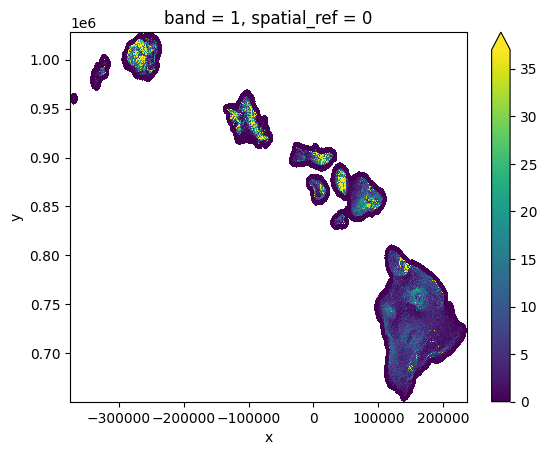

In [6]:
raster_slope2 = raster_slope.where(raster_slope != -9999) # this converts -9999 -> NaN
raster_slope2.plot(robust=True)

In [7]:
print(raster_slope2.min())
print(raster_slope2.max())
print(raster_slope2.mean())
print(raster_slope2.std())
print(raster_slope2.quantile([0.25, 0.75]))

<xarray.DataArray ()> Size: 4B
array(0., dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
<xarray.DataArray ()> Size: 4B
array(79., dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
<xarray.DataArray ()> Size: 4B
array(5.853836, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
<xarray.DataArray ()> Size: 4B
array(8.966055, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
<xarray.DataArray (quantile: 2)> Size: 16B
array([0., 7.])
Coordinates:
  * quantile  (quantile) float64 16B 0.25 0.75


In [8]:
df_slope = raster_slope2.to_dataframe(name='slope').reset_index()

In [9]:
df_slope

,band,y,x,spatial_ref,slope
0,1,1.028238e+06,-375120.0,0,NaN
1,1,1.028238e+06,-375090.0,0,NaN
2,1,1.028238e+06,-375060.0,0,NaN
3,1,1.028238e+06,-375030.0,0,NaN
4,1,1.028238e+06,-375000.0,0,NaN
...,...,...,...,...,...
256891765,1,6.502080e+05,236280.0,0,NaN
256891766,1,6.502080e+05,236310.0,0,NaN
256891767,1,6.502080e+05,236340.0,0,NaN
256891768,1,6.502080e+05,236370.0,0,NaN
